# Reinforcement session for Spearman's rank correlation coefficient (ρ)

In [1]:
# ============================================================
# 📘 Spearman’s Rank Correlation (ρ) — Interactive EDA Exercise
# ============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

# Set plotting style
sns.set(style="whitegrid", context="talk")
np.random.seed(42)

# 1️⃣ Create a small synthetic dataset
n = 50
x = np.linspace(0, 10, n)

# Create different types of relationships
y_linear = 2 * x + np.random.normal(0, 2, n)
y_monotonic = np.log(x + 1) * 10 + np.random.normal(0, 1, n)
y_nonmonotonic = np.sin(x) * 10 + np.random.normal(0, 1, n)

df = pd.DataFrame({
    "x": x,
    "y_linear": y_linear,
    "y_monotonic": y_monotonic,
    "y_nonmonotonic": y_nonmonotonic
})

df.head()


,x,y_linear,y_monotonic,y_nonmonotonic
0,0.000000,0.993428,0.324084,-1.415371
1,0.204082,0.131635,1.472089,1.606034
2,0.408163,2.111704,2.745940,3.626527
3,0.612245,4.270550,5.387952,4.944783
4,0.816327,1.164346,6.999160,7.125062


In [2]:
# 2️⃣ Compute correlations: Pearson vs Spearman

correlations = {
    "Linear Relationship": {
        "Pearson": pearsonr(df.x, df.y_linear)[0],
        "Spearman": spearmanr(df.x, df.y_linear)[0]
    },
    "Monotonic (Log)": {
        "Pearson": pearsonr(df.x, df.y_monotonic)[0],
        "Spearman": spearmanr(df.x, df.y_monotonic)[0]
    },
    "Non-Monotonic (Sine)": {
        "Pearson": pearsonr(df.x, df.y_nonmonotonic)[0],
        "Spearman": spearmanr(df.x, df.y_nonmonotonic)[0]
    }
}

pd.DataFrame(correlations).T.round(3)


,Pearson,Spearman
Linear Relationship,0.950,0.951
Monotonic (Log),0.946,0.983
Non-Monotonic (Sine),-0.086,-0.089


**🧠 Interpretation:** 
* Pearson assumes linear correlation.
* Spearman only needs monotonicity (consistent up or down trend).
* When the relationship curves (e.g., sine), Pearson drops faster than Spearman.

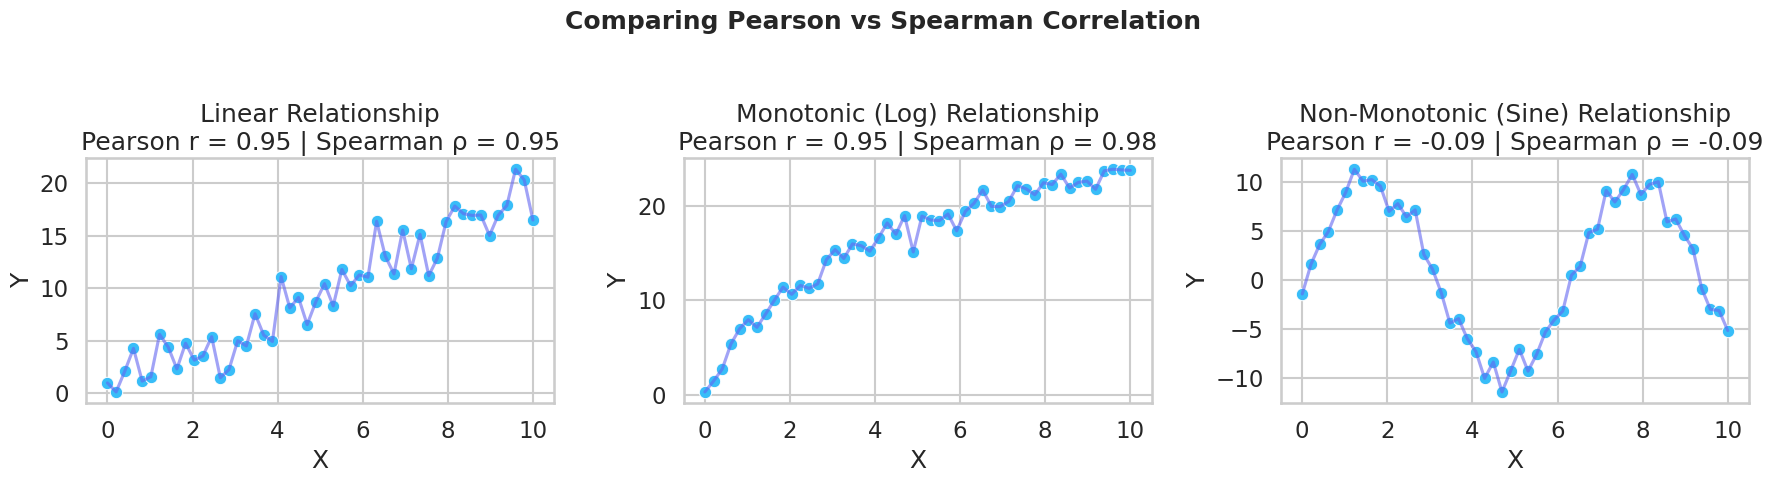

In [3]:
# 3️⃣ Visualize the relationships
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    ("y_linear", "Linear Relationship"),
    ("y_monotonic", "Monotonic (Log) Relationship"),
    ("y_nonmonotonic", "Non-Monotonic (Sine) Relationship")
]

for ax, (ycol, title) in zip(axes, pairs):
    sns.scatterplot(data=df, x="x", y=ycol, ax=ax, color="#38bdf8", s=80, edgecolor="white")
    sns.lineplot(x=df.x, y=df[ycol], ax=ax, color="#6366f1", alpha=0.6)
    pear = pearsonr(df.x, df[ycol])[0]
    spear = spearmanr(df.x, df[ycol])[0]
    ax.set_title(f"{title}\nPearson r = {pear:.2f} | Spearman ρ = {spear:.2f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.suptitle("Comparing Pearson vs Spearman Correlation", fontsize=18, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Save figure to reports/figures
# save_path = "reports/figures/spearman_vs_pearson_comparison.png"
# plt.savefig(save_path, dpi=300, bbox_inches="tight")

# from src.helpers import save_and_log_plot
# save_and_log_plot(fig, "../reports/figures/spearman_vs_pearson_comparison.png",
#                   df=None, chart_type="scatterpanel", library="matplotlib",
#                   notes="Pearson vs Spearman demo", timestamped=True)

# from src.helpers import save_and_log_plot
# save_and_log_plot(
#     plt.gcf(),
#     "reports/figures/spearman_vs_pearson_comparison.png",
#     df=df,
#     chart_type="scatterpair",
#     library="matplotlib",
#     x="x",
#     y="y_linear",
#     dataset_name="spearman_demo",
#     dataset_path="data/processed/spearman_demo.csv",
#     notebook="notebooks/05B_ToStudyFromS1toS5.ipynb",
#     notes="Spearman vs Pearson comparison — visual + numeric.",
#     timestamped=True
# )

plt.show()

# print(f"✅ Plot saved to: {save_path}")


# 📘 Spearman’s Rank Correlation (ρ) — EDA Reinforcement Lab

## 🎯 Objective
Understand how **Spearman’s rank correlation (ρ)** differs from **Pearson’s correlation (r)** and learn when to use each during Exploratory Data Analysis (EDA).

---

## 🧩 Overview

| Correlation Type | Captures | Sensitive To | Best For |
|------------------|-----------|--------------|----------|
| **Pearson (r)** | Linear relationships | Outliers, nonlinearity | Continuous numeric data |
| **Spearman (ρ)** | Monotonic relationships (rank order) | Less sensitive to outliers | Ordinal or nonlinear monotonic data |

> **Intuition:**  
> Spearman doesn’t care *how far apart* two values are — only *which one is bigger.*  
> It looks at **ranks**, not **raw numbers**.

---

## 🧮 Step 1: Generate Data

We’ll create three types of relationships to illustrate correlation behavior:

1. **Linear** — direct straight-line relationship  
2. **Monotonic (log)** — always increasing but not linear  
3. **Non-monotonic (sine)** — oscillates up and down  

---

## 📊 Step 2: Compute Pearson vs Spearman

Both coefficients range from **-1 to +1**:
- +1 → perfect increasing relationship  
- -1 → perfect decreasing relationship  
- 0 → no correlation  

We’ll compute both using:

```python
from scipy.stats import pearsonr, spearmanr


# 🧠 5️⃣ Endogeneity (Regression)
## 🧩 Step 1: ELI5 — Visual Metaphor

| Concept         | Analogy                                                                                                                               |
| --------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| **Exogeneity**  | You’re testing how coffee affects alertness — but random people choose how much coffee they drink.                                    |
| **Endogeneity** | People who are *more tired* drink *more coffee* — so the “effect” of coffee is tangled up with unobserved tiredness (the error term). |


In [3]:
# 📊 Step 2: Generate and visualize endogeneity
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

np.random.seed(42)

# --- Exogenous model ---
n = 200
X_exog = np.random.normal(0, 1, n)
eps_exog = np.random.normal(0, 1, n)
y_exog = 2 + 3*X_exog + eps_exog

# --- Endogenous model ---
u = np.random.normal(0, 1, n)
v = np.random.normal(0, 1, n)
# Introduce correlation between regressor and error
eps_endo = v + 0.8*u
X_endo = 0.5*u + np.random.normal(0, 1, n)
y_endo = 1 + 2*X_endo + eps_endo

# Combine
df = pd.DataFrame({
    "X_exog": X_exog, "y_exog": y_exog,
    "X_endo": X_endo, "y_endo": y_endo
})

# Run OLS on both
ols_exog = sm.OLS(df["y_exog"], sm.add_constant(df["X_exog"])).fit()
ols_endo = sm.OLS(df["y_endo"], sm.add_constant(df["X_endo"])).fit()

ols_exog.summary().tables[1], ols_endo.summary().tables[1]

print("ols_exog/enog loaded")


ols_exog/enog loaded


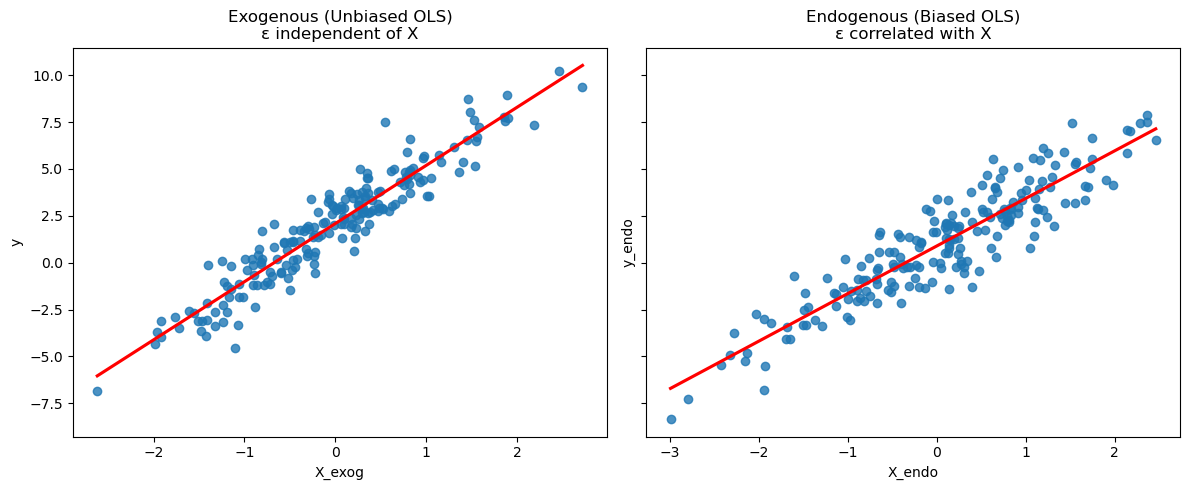

In [4]:
# 🎨 Step 3: Visualize Bias from Endogeneity
# import matplotlib.font_manager as fm
# import matplotlib.pyplot as plt

# # Optional: pick a font that supports emoji (macOS example)
# # plt.rcParams['font.family'] = 'Apple Color Emoji'   # macOS
# # or Windows
# # plt.rcParams['font.family'] = 'Segoe UI Emoji'
# # or Linux (Noto supports many Unicode glyphs)
# plt.rcParams['font.family'] = 'Noto Color Emoji'

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.regplot(x="X_exog", y="y_exog", data=df, ax=axes[0], ci=None, line_kws={'color':'red'})
# axes[0].set_title("Exogenous (✓ unbiased OLS)\nε ⟂ X")
# axes[0].set_title("✅ Exogenous (Unbiased OLS)\nε independent of X")
axes[0].set_title("Exogenous (Unbiased OLS)\nε independent of X")

axes[0].set_xlabel("X_exog")
axes[0].set_ylabel("y")

sns.regplot(x="X_endo", y="y_endo", data=df, ax=axes[1], ci=None, line_kws={'color':'red'})
# axes[1].set_title("Endogenous (⚠ biased OLS)\nε ↔ X")
# axes[1].set_title("⚠️ Endogenous (Biased OLS)\nε correlated with X")
axes[1].set_title("Endogenous (Biased OLS)\nε correlated with X")
axes[1].set_xlabel("X_endo")





plt.tight_layout()
# plt.savefig("../reports/figures/endogeneity_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


🔍 **Interpretation**: 

* Left panel: True slope ≈ 3, estimated slope ≈ 3 ✅ unbiased
* Right panel: True slope = 2, but regression might estimate ≈ 2.7 ⚠️ biased upward

**Why?**
Because X is correlated with the error term → part of ε leaks into X.

🧾 **Step 4: Diagnosing Endogeneity**

There’s no simple “one-click” test, but some clues:

| Diagnostic                                        | Meaning                                  |
| ------------------------------------------------- | ---------------------------------------- |
| Residuals correlated with predictors              | Violation of OLS independence assumption |
| High R² but weird sign on coefficient             | Suspicious correlation                   |
| Time-series “simultaneity” (e.g., price ↔ demand) | Mutual causation                         |
| Omitted variable suspected                        | Hidden factor drives both X and y        |


In [7]:
# Quick correlation check (simplistic diagnostic):
corr = np.corrcoef(df["X_endo"], ols_endo.resid)[0,1]
print(f"Corr(X, residuals) = {corr:.2f}")


Corr(X, residuals) = -0.00


In [8]:
corr = np.corrcoef(df["X_exog"], ols_endo.resid)[0,1]
print(f"Corr(X, residuals) = {corr:.2f}")


Corr(X, residuals) = 0.01


🧪 **Step 5: Fixes for Endogeneity**
| Type                  | Example Fix                   | Tool / Technique              |
| --------------------- | ----------------------------- | ----------------------------- |
| **Omitted variable**  | Add missing relevant variable | Include confounders           |
| **Simultaneity**      | Find instrument               | Instrumental Variables (2SLS) |
| **Measurement error** | Use proxy variable            | IV, structural modeling       |
| **Reverse causality** | Random assignment             | Randomized experiments        |


In [5]:
#conda install -c conda-forge linearmodels
from linearmodels.iv import IV2SLS
print("✅ linearmodels imported successfully!")


✅ linearmodels imported successfully!


In [9]:
# # 🛠 Example (Instrumental Variable Setup)
# from linearmodels.iv import IV2SLS

# # Create instrument Z (correlated with X_endo, uncorrelated with ε)
# Z = 0.5*u + np.random.normal(0, 1, n)
# df["Z"] = Z

# # 2SLS: y = β0 + β1*X + ε, instrumented by Z
# iv_model = IV2SLS(df["y_endo"], sm.add_constant(df["X_endo"]),
#                   instrument=sm.add_constant(df["Z"])).fit()

# print(iv_model.summary)

import pandas as pd
import statsmodels.api as sm
from linearmodels.iv import IV2SLS

# --- Data columns we already have from your simulation ---
# y_endo : dependent variable
# X_endo : endogenous regressor (needs instrument)
# Z      : instrument (correlated with X_endo, uncorrelated with error)

y = df["y_endo"]                         # dependent
exog = pd.DataFrame({"const": 1.0}, index=df.index)  # exogenous part (just a constant)
endog = df[["X_endo"]]                   # endogenous regressor(s) MUST be 2D
instruments = df[["Z"]]                  # instrument(s) MUST be 2D

# --- OLS (biased when X_endo is endogenous) ---
ols_model = sm.OLS(y, sm.add_constant(df[["X_endo"]])).fit()

# --- 2SLS (IV) with correct arguments ---
iv_model = IV2SLS(dependent=y,
                  exog=exog,
                  endog=endog,
                  instruments=instruments).fit()

print("=== OLS (potentially biased) ===")
print(ols_model.summary().tables[1])

print("\n=== 2SLS / IV (consistent under valid instrument) ===")
print(iv_model.summary)



=== OLS (potentially biased) ===
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8947      0.087     10.262      0.000       0.723       1.067
X_endo         2.5360      0.080     31.690      0.000       2.378       2.694

=== 2SLS / IV (consistent under valid instrument) ===
                          IV-2SLS Estimation Summary                          
Dep. Variable:                 y_endo   R-squared:                      0.7762
Estimator:                    IV-2SLS   Adj. R-squared:                 0.7750
No. Observations:                 200   F-statistic:                    72.011
Date:                Tue, Nov 04 2025   P-value (F-stat)                0.0000
Time:                        16:00:46   Distribution:                  chi2(1)
Cov. Estimator:                robust                                         
                                           

# 📚 Step 6: Best Practices Checklist
| ✅ Action                                  | Purpose                                           |
| ----------------------------------------- | ------------------------------------------------- |
| Check correlation between X and residuals | Quick sanity test                                 |
| Simulate or visualize correlated error    | Helps intuition                                   |
| Identify potential instruments            | Needed for IV regression                          |
| Avoid post-treatment bias                 | Don’t include variables affected by the treatment |
| Verify via domain knowledge               | Endogeneity ≠ purely statistical issue            |


#  🧠 Step 7: Reinforcement Exercises 
**🧩 Try these yourself:**
1. Modify the noise correlation (e.g., 0.8*u → 0.3*u) and see how the bias changes.
1. Simulate a reverse-causality scenario (e.g., income affects education and vice versa).
1. Add an instrumental variable and confirm bias reduction.
1. Plot residuals vs X and interpret correlation visually.
1. Run the same simulation with more noise (heteroscedastic ε) and see if the slope stabilizes or worsens.

# 📖 Step 8: ELI5 Summary
* Endogeneity = predictor “cheats” by knowing the error term.
* OLS assumes predictors and errors are strangers — endogeneity breaks that friendship.
* Fix with instruments or randomization to restore fairness.

🧩 **Visual mnemonic**:

A sneaky feature whispers into ε’s ear — your regression hears gossip and becomes biased.
| Concept           | Key Idea                                    | Fix                     |
| ----------------- | ------------------------------------------- | ----------------------- |
| **Endogeneity**   | X correlated with ε → OLS bias              | Use IV / Randomization  |
| **Exogeneity**    | X independent of ε                          | OLS unbiased            |
| **Diagnosis**     | Corr(X, residuals) ≠ 0                      | Inspect model residuals |
| **Visualization** | Compare exog vs endog regressions           | Plot + summary stats    |
| **Tools**         | `IV2SLS`, `linearmodels`, randomized design | Advanced fix            |
